# Simulation studies for 'Achieving and Assessing Calibration in Many Tests'
Adway Wadekar

In [75]:
import numpy as np
import pandas as pd
from npeb import Grenander, local_fdr
import scipy.stats as stats
from scipy.io import loadmat
from scipy.integrate import quad
import matplotlib.pyplot as plt
from scipy.optimize import isotonic_regression

## Helper functions

In [3]:
# function to make simulated p-values
def make_pvals(n, pi0, alpha = 0.5, beta = 1.0):
    n0 = int(pi0 * n)
    n1 = n - n0
    pvals = np.concatenate([np.random.uniform(size=n0), np.random.beta(a=alpha, b=beta, size=n1)])
    labels = np.concatenate([np.zeros(n0), np.ones(n1)])
    perm = np.random.permutation(n)
    pvals = pvals[perm]
    labels = labels[perm]
    return labels, pvals

# make q-values from p-values
def qvalues(pvals, lam=0.5):
    pvals = np.asarray(pvals)
    m = len(pvals)

    # sort p-values
    order = np.argsort(pvals)
    p_sorted = pvals[order]

    # estimate pi0
    pi0 = np.mean(pvals > lam) / (1 - lam)
    pi0 = min(pi0, 1.0)

    # compute initial q-values (i.e. pFDRs for each p-value)
    qvals = m * p_sorted * pi0 / np.arange(1, m + 1)

    # enforce monotonicity by taking minimum at each step
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]
    qvals = np.minimum(qvals, 1.0)

    # return in original order
    # q_original = np.empty_like(qvals)
    # q_original[order] = qvals

    q_original = qvals[np.argsort(order)]

    return q_original

def mixture_density(x, pi0, alpha, beta):
    return pi0 + (1 - pi0) * stats.beta.pdf(x, a=alpha, b=beta)

def conditional_mean(x, pi0, alpha, beta):
    return pi0 / mixture_density(x, pi0, alpha, beta)

def integral(i, pi0, alpha, beta, knots, heights):
    def integrand(x):
        return mixture_density(x, pi0, alpha, beta) * (conditional_mean(x, pi0, alpha, beta) - heights[i])**2
    return quad(integrand, knots[i], knots[i+1])[0]

def total_integral(pi0, alpha, beta, knots, heights):
    return sum(integral(i, pi0, alpha, beta, knots, heights) for i in range(len(knots) - 1))

In [4]:
def calibrate_and_assess(pvals, labels, lam = 0.5, n_bins = 10, calibrator = "p-value", pi0 = 0.90, alpha = 0.5, beta = 2.3):
  pi_0_hat = np.mean(pvals > lam) / (1 - lam)
  if calibrator == "p-value":
    stat_df = pd.DataFrame({"p_val": pvals, "label": labels})
    bins = np.linspace(0, 1, n_bins + 1)
    stat_df["bin"] = pd.cut(stat_df["p_val"], bins=bins, include_lowest=True, right = True)
    bin_stats = stat_df.groupby("bin").agg(
        p_min = ("p_val", "min"),
        p_max = ("p_val", "max"),
        p_mean = ("p_val", "mean"),
        p_bin_length = ("p_val", lambda x: x.max() - x.min()),
        stat_mean = ("p_val", "mean"),
        count = ("p_val", "count"),
        proportion_true_nulls = ("label", lambda x: 1 - np.mean(x)),
    ).reset_index()
    bin_stats["proportion_true_nulls_hat"] = np.minimum(pi_0_hat * bin_stats["p_bin_length"] * len(stat_df["p_val"])/ bin_stats["count"], 1)
  elif calibrator == "q-value":
    qvals = qvalues(pvals, lam = lam)
    stat_df = pd.DataFrame({"p_val": pvals, "q_val": qvals, "label": labels})
    bins = np.linspace(0, 1, n_bins + 1)
    stat_df["bin"] = pd.cut(stat_df["q_val"], bins=bins, include_lowest=True, right = True)
    bin_stats = stat_df.groupby("bin").agg(
        p_min = ("p_val", "min"),
        p_max = ("p_val", "max"),
        p_mean = ("p_val", "mean"),
        p_bin_length = ("p_val", lambda x: x.max() - x.min()),
        stat_mean = ("q_val", "mean"),
        count = ("p_val", "count"),
        proportion_true_nulls = ("label", lambda x: 1 - np.mean(x)),
    ).reset_index()
    bin_stats["proportion_true_nulls_hat"] = np.minimum(pi_0_hat * bin_stats["p_bin_length"] * len(stat_df["p_val"])/ bin_stats["count"], 1)

  elif calibrator == "lfdr":
    train_idx = np.random.choice(len(pvals), size=int(0.5 * len(pvals)), replace=False)
    train_pvals = pvals[train_idx]
    train_labels = labels[train_idx]
    test_pvals = pvals[~np.isin(pvals, train_pvals)]
    test_labels = labels[~np.isin(pvals, train_pvals)]

    gren = Grenander(x_min=0, x_max=1.0)
    fhat = gren.fit(train_pvals)
    lam = 1 - len(test_pvals)**(-1/5)

    pi_hat_0_gren = np.mean(test_pvals > lam) / (1 - lam)
    gren.pdf(test_pvals)
    test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)

    stat_df = pd.DataFrame({"p_val": test_pvals, "lfdr": test_lfdr, "label": test_labels})
    bins = np.linspace(0, 1, n_bins + 1)
    stat_df["bin"] = pd.cut(stat_df["lfdr"], bins=bins, include_lowest=True, right = True)
    bin_stats = stat_df.groupby("bin").agg(
        p_min = ("p_val", "min"),
        p_max = ("p_val", "max"),
        p_mean = ("p_val", "mean"),
        p_bin_length = ("p_val", lambda x: x.max() - x.min()),
        stat_mean = ("lfdr", "mean"),
        count = ("p_val", "count"),
        proportion_true_nulls = ("label", lambda x: 1 - np.mean(x)),
    ).reset_index()
    bin_stats["proportion_true_nulls_hat"] = np.minimum(pi_hat_0_gren * bin_stats["p_bin_length"] * len(stat_df["p_val"])/ bin_stats["count"], 1)
  
  calibration_error = None
  if calibrator == "p-value":
    def integrand(x):
        return mixture_density(x, pi0, alpha, beta) * (conditional_mean(x, pi0, alpha, beta) - x)**2
    calibration_error = quad(integrand, 0, 1)[0]
  elif calibrator == "q-value":
    # append zero and one to pvals and save as knots
    order = np.argsort(pvals)
    knots = np.concatenate([[0], pvals[order], [1]])
    heights = np.concatenate([[qvals[order][0]], qvals[order], [1]])
    calibration_error = total_integral(pi0, alpha, beta, knots, heights)
  elif calibrator == "lfdr":
    knots = gren.knots
    heights = np.minimum(pi_hat_0_gren / gren.slopes, 1)
    calibration_error = total_integral(pi0, alpha, beta, knots, heights)
  return calibration_error, bin_stats

## Example experiment (lfdr calibration)

In [20]:
labels, pvals = make_pvals(n=50_000, pi0=0.75, alpha=0.5, beta=2.3)
qvals = qvalues(pvals, lam=0.5)

train_idx = np.random.choice(len(pvals), size=int(0.5 * len(pvals)), replace=False)
train_pvals = pvals[train_idx]
train_labels = labels[train_idx]
test_pvals = pvals[~np.isin(pvals, train_pvals)]
test_labels = labels[~np.isin(pvals, train_pvals)]

In [21]:
gren = Grenander(x_min=0, x_max=1.0)
fhat = gren.fit(train_pvals)
lam = 1 - len(test_pvals)**(-1/5)
pi_hat_0_gren = np.mean(test_pvals > lam) / (1 - lam)
gren.pdf(test_pvals)
test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)

/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_67203/3169483279.py:6: RuntimeWarning: divide by zero encountered in divide
  test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)


          lfdr_bin         p_min     p_max    p_mean  lfdr_mean  count  \
0  (-0.001, 0.111]  9.750453e-09  0.001556  0.000527   0.067585    428   
1   (0.111, 0.222]  1.565236e-03  0.004352  0.002864   0.175777    353   
2   (0.222, 0.333]  4.354852e-03  0.015088  0.009289   0.264865    782   
3   (0.333, 0.444]  1.510989e-02  0.043590  0.028651   0.418452   1374   
4   (0.444, 0.556]  4.361842e-02  0.086865  0.064302   0.507408   1612   
5   (0.556, 0.667]  8.697931e-02  0.163767  0.124747   0.631185   2352   
6   (0.667, 0.778]  1.638487e-01  0.282977  0.222469   0.734048   3099   
7   (0.778, 0.889]  2.829895e-01  0.448249  0.364288   0.843336   3859   
8     (0.889, 1.0]  4.484174e-01  0.725808  0.585027   0.951954   5803   

   proportion_true_nulls  p_bin_length  true_nulls_hat  \
0               0.051402      0.001556       30.640576   
1               0.172805      0.002786       54.883952   
2               0.278772      0.010733      211.406992   
3               0.384279   

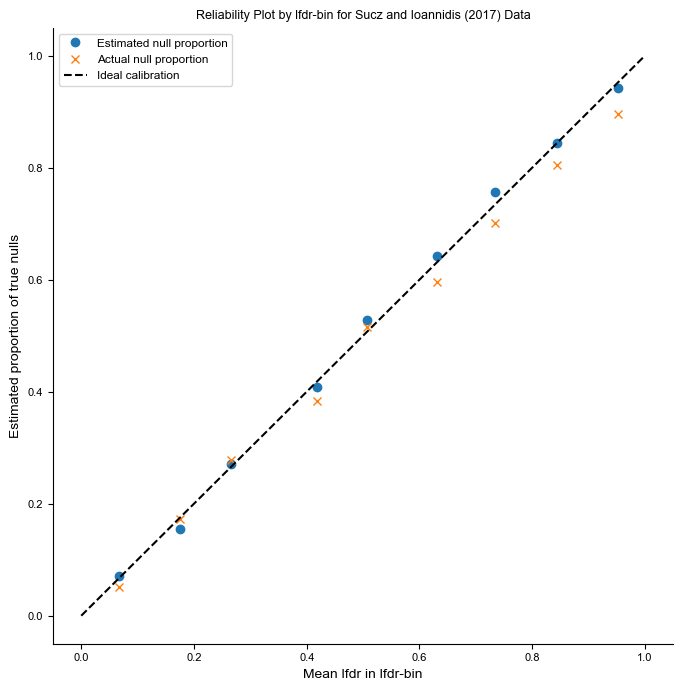

In [22]:
test_df = pd.DataFrame({
    'p_value': test_pvals,
    'lfdr': test_lfdr,
    'label': test_labels
})

# lfdr bins
bins = np.linspace(0, 1, 10)

# put lfdr  into bins
# df["lfdr_bin"] = pd.cut(df["lfdr"], bins=bins, include_lowest=True, right=True)
test_df["lfdr_bin"] = pd.cut(test_df["lfdr"], bins=bins, include_lowest=True, right=True)

# m = len(df)
m = len(test_df)

# summarize p-values within each lfdr-bin
lfdr_bin_stats = (
    test_df.groupby("lfdr_bin", observed=False)
      .agg(
          p_min=("p_value", "min"),
          p_max=("p_value", "max"),
          p_mean=("p_value", "mean"),
          lfdr_mean=("lfdr", "mean"),
          count=("p_value", "size"),
          proportion_true_nulls = ("label", "mean")
      )
      .reset_index()
)

lfdr_bin_stats["proportion_true_nulls"] = 1 - lfdr_bin_stats["proportion_true_nulls"]

# empirical p-range length induced by each lfdr-bin
lfdr_bin_stats["p_bin_length"] = lfdr_bin_stats["p_max"] - lfdr_bin_stats["p_min"]

# expected number of nulls in that p-interval under Storey's estimate
lfdr_bin_stats["true_nulls_hat"] = pi_hat_0_gren * m * lfdr_bin_stats["p_bin_length"]

# estimated null proportion within the lfdr-bin
lfdr_bin_stats["proportion_true_nulls_hat"] = np.minimum(
    lfdr_bin_stats["true_nulls_hat"] / lfdr_bin_stats["count"],
    1.0
)

lfdr_bin_stats["lfdr_bin_start"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.left)
lfdr_bin_stats["lfdr_bin_end"] = lfdr_bin_stats["lfdr_bin"].apply(lambda x: x.right)

print(lfdr_bin_stats)

# plot reliability plot for lfdr bins (estimated null proportion vs. mean lfdr in bin)

plt.figure(figsize=(8, 8))

plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls_hat"], "o", label="Estimated null proportion")
plt.plot(lfdr_bin_stats["lfdr_mean"], lfdr_bin_stats["proportion_true_nulls"], "x", label="Actual null proportion")

plt.plot([0, 1], [0, 1], "k--", label="Ideal calibration")

plt.xlabel("Mean lfdr in lfdr-bin")
plt.ylabel("Estimated proportion of true nulls")
plt.title("Reliability Plot by lfdr-bin for Sucz and Ioannidis (2017) Data")

plt.legend()
plt.show()

## Experiments

In [42]:
# run experiments for different calibrators and compare calibration errors
# surpress errors for block
M = 75
# pi0s = [0.5, 0.75, 0.9]
# alphas = [0.5, 0.7, 0.95]
pi0s = [0.75]
alphas = [1.8]
beta = 2.3
results = []
for pi0 in pi0s:
  for alpha in alphas:
    for i in range(M):
      for n in [500, 1000, 5_000]:
        labels, pvals = make_pvals(n=n, pi0=pi0, alpha=alpha, beta=beta)
        lam = 1 - len(pvals)**(-1/5)
        for calibrator in ["lfdr", "q-value", "p-value"]:  
          calibration_error, bin_stats = calibrate_and_assess(pvals, labels, lam=lam, n_bins=10, calibrator=calibrator, pi0=pi0, alpha=alpha, beta=beta)
          results.append({
              "n": n,
              "calibrator": calibrator,
              "calibration_error": calibration_error
          })

/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_57954/1442848429.py:75: RuntimeWarning: divide by zero encountered in divide
  heights = np.minimum(pi_hat_0_gren / gren.slopes, 1)
/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_57954/1442848429.py:46: RuntimeWarning: divide by zero encountered in divide
  test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)
/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_57954/1442848429.py:75: RuntimeWarning: divide by zero encountered in divide
  heights = np.minimum(pi_hat_0_gren / gren.slopes, 1)
/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_57954/1442848429.py:46: RuntimeWarning: divide by zero encountered in divide
  test_lfdr = pi_hat_0_gren / gren.pdf(test_pvals)
/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipykernel_57954/1442848429.py:75: RuntimeWarning: divide by zero encountered in divide
  heights = np.minimum(pi_hat_0_gren / gren.slopes, 1)
/var/folders/2p/pvl5m11d621fk0xffszjtbw80000gn/T/ipyk

In [31]:
# aggregate results by calibrator, oracle vs. non-oracle, n
results_df = pd.DataFrame(results)
summary_df = results_df.groupby(["calibrator", "n"]).agg(
    mean_brier_regret = ("calibration_error", "mean"),
    std_brier_regret = ("calibration_error", "std")
).reset_index()

summary_df

NameError: name 'results' is not defined

NameError: name 'summary_df' is not defined

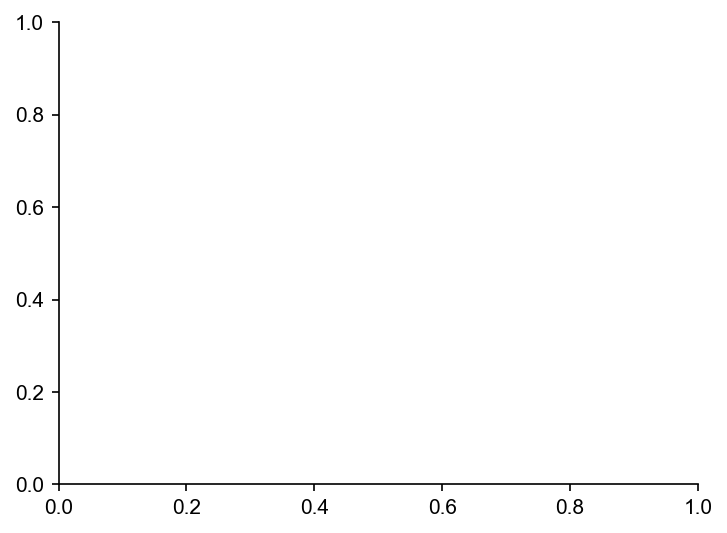

In [30]:
# NeurIPS-ish clean plotting defaults
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(5.5, 4.0))

for calibrator in sorted(summary_df["calibrator"].unique()):
    subset = (
        summary_df[summary_df["calibrator"] == calibrator]
        .sort_values("n")
    )
    
    ax.errorbar(
        subset["n"],
        subset["mean_brier_regret"],
        yerr=subset["std_brier_regret"],
        marker="o",
        markersize=4.5,
        linewidth=1.8,
        capsize=3,
        elinewidth=1.2,
        label=calibrator,
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"Number of tests, $n$")
ax.set_ylabel("Brier regret")
ax.set_title("Brier regret vs. number of tests", pad=8)

ax.grid(True, which="major", linewidth=0.6, alpha=0.35)
ax.grid(True, which="minor", linewidth=0.3, alpha=0.18)

ax.legend(
    frameon=False,
    loc="best",
    handlelength=2.0,
)

fig.tight_layout()

In [72]:
# get rates of decay of calibration error with n for each calibrator by fitting a line to the log-log plot
from scipy.stats import linregress

for calibrator in summary_df["calibrator"].unique():
    subset = summary_df[summary_df["calibrator"] == calibrator]
    log_n = np.log(subset["n"])
    log_error = np.log(subset["mean_brier_regret"])
    slope, intercept, r_value, p_value, std_err = linregress(log_n, log_error)
    print(f"Calibrator: {calibrator}, Rate of decay: {slope:.2f}, R-squared: {r_value**2:.4f}")

Calibrator: lfdr, Rate of decay: -0.59, R-squared: 0.9971
Calibrator: p-value, Rate of decay: 0.00, R-squared: nan
Calibrator: q-value, Rate of decay: -0.02, R-squared: 0.7162


## Analyze cluster simulations

In [73]:
# load csv
results_df = pd.read_csv("../data/sim_summary.csv")
results_df

,pi0,alpha,beta,n,calibrator,mean_calibration_error,sd_calibration_error,n_success
0,0.5,0.5,2.3,500,lfdr,0.011015,0.008015,500
1,0.5,0.5,2.3,500,p-value,0.029609,0.000000,500
2,0.5,0.5,2.3,500,q-value,0.066824,0.017457,500
3,0.5,0.5,2.3,1000,lfdr,0.007440,0.005423,500
4,0.5,0.5,2.3,1000,p-value,0.029609,0.000000,500
...,...,...,...,...,...,...,...,...
175,0.9,1.5,2.3,10000,p-value,0.232604,0.000000,500
176,0.9,1.5,2.3,10000,q-value,0.002263,0.001070,500
177,0.9,1.5,2.3,50000,lfdr,0.000818,0.000485,500
178,0.9,1.5,2.3,50000,p-value,0.232604,0.000000,500


In [77]:
def monotone_adjustment(pi0, alpha, beta, B):
  if alpha <= 1:
    raise ValueError("Alpha must be greater than 1 to need monotone adjustment.")
  n0 = int(pi0 * B)
  n1 = B - n0
  p_vals = np.concatenate([np.random.uniform(size=n0), np.random.beta(a=alpha, b=beta, size=n1)])
  p_vals = np.sort(p_vals)

  lfdr_mc = conditional_mean(p_vals, pi0, alpha, beta)
  lfdr_iso = isotonic_regression(lfdr_mc, increasing=True)
  lfdr_uparrow_mc = lfdr_iso.x

  return np.mean((lfdr_uparrow_mc - lfdr_mc)**2)

In [79]:
# for alpha = 1.5 in results_df, subtract off monotone adjustment error from mean brier regret, for each beta and pi_0
B = 10_000_000

# subtract off 
results_df["monotone_adjustment_error"] = results_df.apply(lambda row: monotone_adjustment(row["pi0"], row["alpha"], row["beta"], B) if row["alpha"] > 1 else 0, axis=1)
results_df["mean_brier_regret_adj"] = results_df["mean_calibration_error"] - results_df["monotone_adjustment_error"]

In [81]:
# save results_df to pickle
results_df.to_pickle("../data/sim_summary.pkl")

If starting from the pkl file, just load the pkl file here and start at this point.

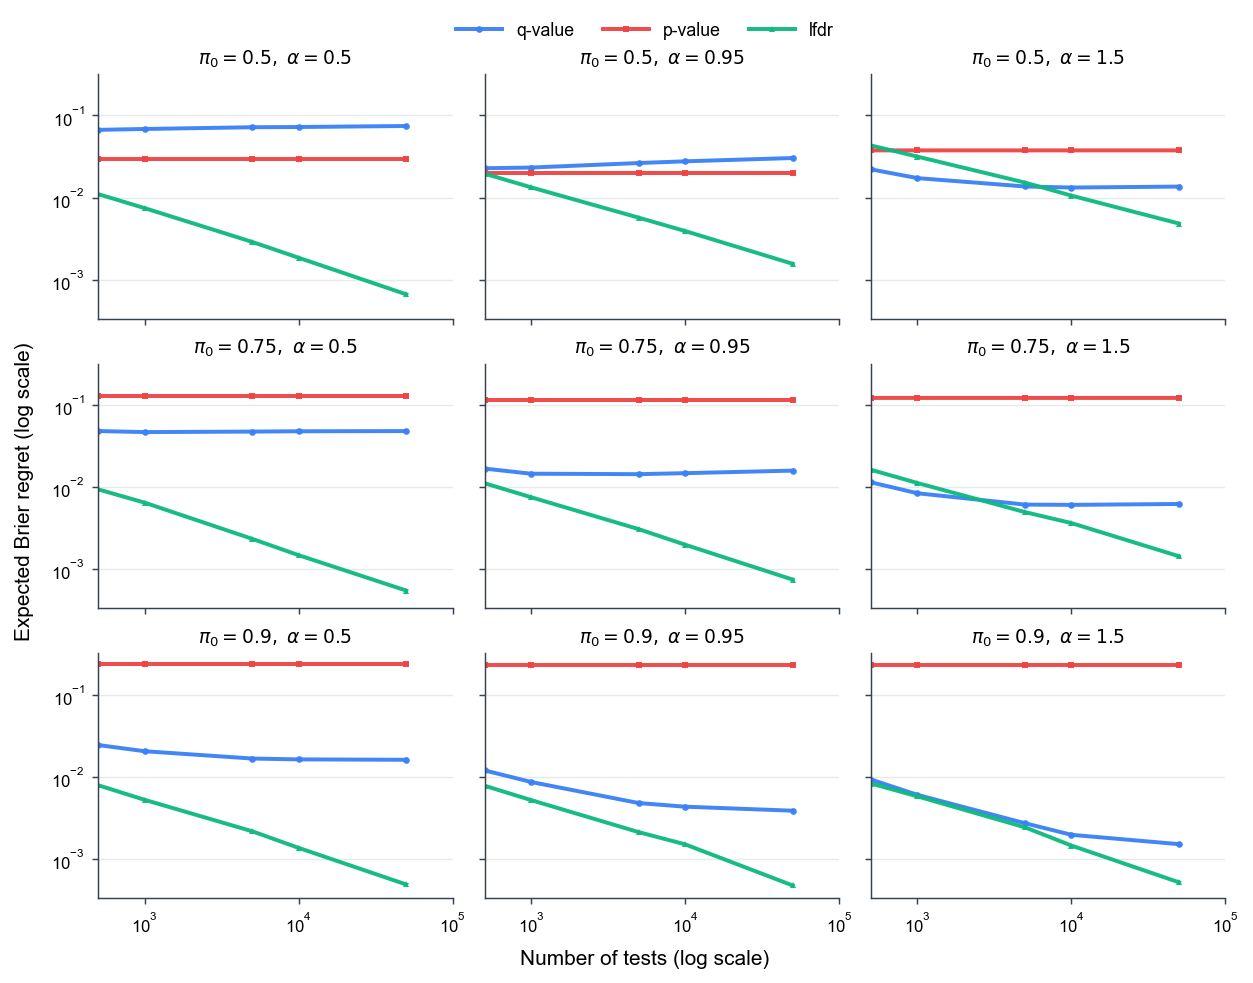

In [85]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter

plot_df = results_df[results_df["alpha"] != 0.7].copy()

pis = np.sort(plot_df["pi0"].unique())
alphas = np.sort(plot_df["alpha"].unique())

calibrators = ['q-value', 'p-value', 'lfdr']

xmin = 5e2
xmax = 1e5

# Modern ML-paper palette: distinct, clean, colorblind-conscious
palette = [
    "#3B82F6",  # blue
    "#EF4444",  # red
    "#10B981",  # emerald
    "#8B5CF6",  # violet
    "#F59E0B",  # amber
    "#06B6D4",  # cyan
    "#EC4899",  # pink
    "#111827",  # near-black
]

linestyles = ["-", "-", "-", "-", "--", "--", "--", "--"]
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]

color_map = dict(zip(calibrators, palette[:len(calibrators)]))
style_map = dict(zip(calibrators, linestyles[:len(calibrators)]))
marker_map = dict(zip(calibrators, markers[:len(calibrators)]))

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 12,
    "axes.titlesize": 9,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, axes = plt.subplots(
    nrows=len(pis),
    ncols=len(alphas),
    figsize=(8, 6),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for i, pi0 in enumerate(pis):
    for j, alpha in enumerate(alphas):
        ax = axes[i, j]

        subset = plot_df[
            (plot_df["pi0"] == pi0) &
            (plot_df["alpha"] == alpha)
        ]

        for calibrator in calibrators:
            calib_subset = subset[
                subset["calibrator"] == calibrator
            ].sort_values("n")

            if calib_subset.empty:
                continue

            x = calib_subset["n"].to_numpy()
            y = calib_subset["mean_brier_regret_adj"].to_numpy()
            se = calib_subset["sd_calibration_error"].to_numpy() / np.sqrt(500)

            ax.plot(
                x,
                y,
                color=color_map[calibrator],
                linestyle=style_map[calibrator],
                marker=marker_map[calibrator],
                markersize=3.2,
                markeredgewidth=0,
                linewidth=1.9,
                alpha=0.96,
                label=calibrator,
            )

            ax.fill_between(
                x,
                np.maximum(y - se, 1e-16),
                y + se,
                color=color_map[calibrator],
                alpha=0.10,
                linewidth=0,
            )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(xmin, xmax)

        ax.xaxis.set_major_locator(LogLocator(base=10))
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.yaxis.set_minor_formatter(NullFormatter())

        ax.set_title(rf"$\pi_0={pi0},\ \alpha={alpha}$", pad=5)

        ax.grid(
            True,
            which="major",
            axis="y",
            color="#E5E7EB",
            linewidth=0.7,
            alpha=0.9,
        )

        ax.tick_params(axis="both", which="major", length=3, width=0.7, color="#374151")
        ax.tick_params(axis="both", which="minor", length=0)

        for spine in ["left", "bottom"]:
            ax.spines[spine].set_color("#374151")
            ax.spines[spine].set_linewidth(0.7)

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=min(len(labels), 4),
    frameon=False,
    bbox_to_anchor=(0.5, 1.04),
    handlelength=2.6,
    columnspacing=1.6,
)

fig.text(
    0.5, -0.025,
    r"Number of tests (log scale)",
    ha="center",
    fontsize=10,
)

fig.text(
    -0.025, 0.5,
    "Expected Brier regret (log scale)",
    va="center",
    rotation="vertical",
    fontsize=10,
)

plt.show()

In [83]:
fig.savefig("calibration_error_grid.pdf", bbox_inches="tight")
fig.savefig("calibration_error_grid.png", dpi=300, bbox_inches="tight")

In [86]:
# calculate rates of decay for each calibrator, pi0, alpha by fitting a line to the log-log plot of calibration error vs. n
from scipy.stats import linregress
decay_results = []
for calibrator in plot_df["calibrator"].unique():
    for pi0 in plot_df["pi0"].unique():
        for alpha in plot_df["alpha"].unique():
            subset = plot_df[
                (plot_df["calibrator"] == calibrator) &
                (plot_df["pi0"] == pi0) &
                (plot_df["alpha"] == alpha)
            ].sort_values("n")

            if subset.empty:
                continue

            log_n = np.log(subset["n"])
            log_error = np.log(subset["mean_brier_regret_adj"])
            slope, intercept, r_value, p_value, std_err = linregress(log_n, log_error)

            decay_results.append({
                "calibrator": calibrator,
                "pi0": pi0,
                "alpha": alpha,
                "decay_rate": slope,
                "r_squared": r_value**2,
            })

decay_df = pd.DataFrame(decay_results)
print(decay_df)

   calibrator   pi0  alpha    decay_rate     r_squared
0        lfdr  0.50   0.50 -6.094852e-01  9.993765e-01
1        lfdr  0.50   0.95 -5.457023e-01  9.996821e-01
2        lfdr  0.50   1.50 -4.753026e-01  9.993661e-01
3        lfdr  0.75   0.50 -6.213923e-01  9.995922e-01
4        lfdr  0.75   0.95 -5.848988e-01  9.993649e-01
5        lfdr  0.75   1.50 -5.201615e-01  9.986323e-01
6        lfdr  0.90   0.50 -6.004119e-01  9.984634e-01
7        lfdr  0.90   0.95 -5.962714e-01  9.953728e-01
8        lfdr  0.90   1.50 -6.012440e-01  9.966240e-01
9     p-value  0.50   0.50  0.000000e+00           NaN
10    p-value  0.50   0.95 -1.752165e-31  4.205195e-31
11    p-value  0.50   1.50  6.369560e-05  7.836906e-01
12    p-value  0.75   0.50  0.000000e+00           NaN
13    p-value  0.75   0.95  0.000000e+00           NaN
14    p-value  0.75   1.50 -4.163900e-06  1.348592e-01
15    p-value  0.90   0.50  0.000000e+00           NaN
16    p-value  0.90   0.95  0.000000e+00           NaN
17    p-va